# **Genomic Data Clustering - Understanding the Genetic Code**


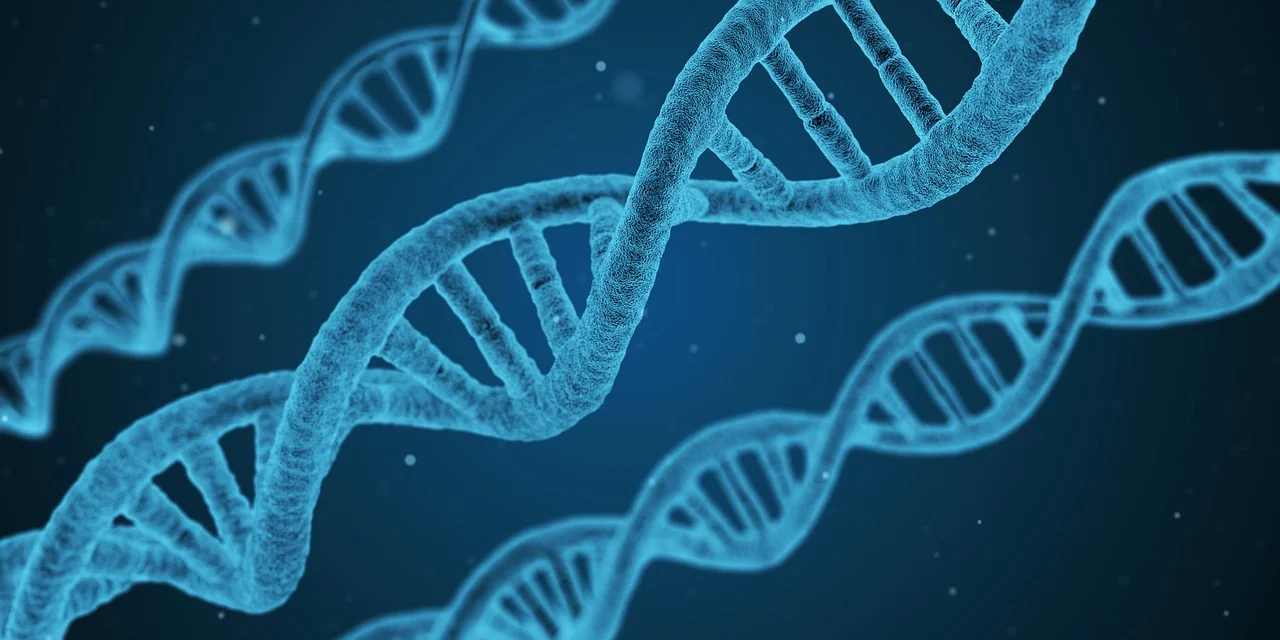

**Source:** [Pixabay](https://pixabay.com/illustrations/dna-helix-string-biology-3d-1811955/)


---------------------
## **Context**
---------------------

The discovery of DNA (Deoxyribonucleic Acid), and the critical role it plays in information storage for all biological beings, was a seminal moment for the biological sciences. All the information that is needed for the functioning of a living cell is encoded in and ultimately derived from the DNA of that cell, and this holds true for all biological organisms on the planet.

**DNA can be represented as a text sequence, with an alphabet that only has four letters** - A (Adenosine), C (Cytosine), G (Guanine), and T (Thymine). The diversity of living organisms and their complex properties is hidden in their genomic sequences. One of the most exciting problems in modern science is to understand the organization of living matter by reading genomic sequences. 

**One distinctive message in a genomic sequence is a piece of text, called a gene**. Genes can be oriented in the sequence in either the forward or backward directions. In the highest organisms (humans, for example), the notion of a gene is more complex. 

It was one of the many great discoveries of the twentieth century, that biological information is encoded in genes through **triplets of letters**, **called codons** in the biological literature. 


------------------------------------
## **About the data**
------------------------------------

The work starts with a fragment of the genomic sequence of the bacterium **Caulobacter crescentus**. This sequence is given as a long text file (300 kb), and the task is to look at the file and ensure that the text uses the alphabet of four letters (A, C, G, and T) and that these letters are used without spaces. It is noticeable that, although the text seems to be random, it is well organized, but we cannot understand it without special tools. Statistical methods may help us do so.

----------------------
## **Objective**
----------------------

In this exercise, we will see that it is possible to **verify the validity of the discovery of three-letter codons**, simply by performing unsupervised machine learning on the genetic sequence.

In this case study, we accept data from a genome and have the goal of identifying useful genes versus noise. Unfortunately, we don't know which sequences of genes are useful, so we have to use Unsupervised Learning to infer this. 

In this notebook, we walk through the following series of steps:

  1. First, the data is imported and prepared. Initially, the sequence, a single string, is split into non-overlapping substrings of length 300, and we may then count the combinations of the distinct 1, 2, 3, and 4-length sequences of base pairs that appear in each possible substring.
  2. PCA is performed to try to identify the internal structure of the data.
  3. Finally, if PCA reveals some internal structure then we'll apply Clustering techniques to the dataset.

## **Importing the libraries**

In [1]:
import pandas as pd

import numpy as np

from tqdm import tqdm

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans 

from sklearn.preprocessing import StandardScaler

## **Data Preparation**

The file format often used for bioinformatics and genomic data is called **FASTA**. It is a normally encoded file with headers separating genetic information. We read the file and strip it of unwanted characters and store it as a string.

In [2]:
# Open the file and get an array of its lines 
with open ("ccrescentus.fa", "r") as inputFile:
    data = inputFile.readlines()

# Concatenate each line from the second (first line is a description), stripped of empty characters 
geneticCode = ''

for line in data[1:]:
    geneticCode += line.strip()
    
# Count the presence of each genome (a, g, t, c)
aCount = geneticCode.count('a')

gCount = geneticCode.count('g')

tCount = geneticCode.count('t')

cCount = geneticCode.count('c')

# For testing, we print a sample of the string and check if there are no wanted characters
print(geneticCode[0:30])

print('Test: only a, g, t, c?')

print(aCount + gCount + tCount + cCount == len(geneticCode))

gccgatagcctatgatccccggcaggcccg
Test: only a, g, t, c?
True


### **Converting Text to a Numerical Table**

#### **Creating Frequency Tables**

Now, we've got a string element containing the sequence. A word is any continuous piece of text that contains several subsequent letters. As there are no spaces in the text, separation into words is not unique. The next step is to separate it into smaller sub-strings and create frequency tables for each x-sized word. We start by separating the string into several sub-strings, of reasonable sample size, to become rows in our table.

**What is a "reasonable size" for a data point?**

Knowing that our string has 305,100 characters and that we are checking words with a maximum of 4 letters, take the size of 300. It generates 1017 data points and allows for 75 4-letter words. It seems reasonable, but do feel free to change it and see the impact. 

We clip the whole text into fragments of 300 letters, and calculate the frequencies of short words (of length 1 - 4) inside every fragment. This will give us a description of the text in the form of a numerical table. There will be four such tables for every short word length choice from 1 to 4. 

As there are only four letters, there are four possible words of length 1 (singlets), 16 = 4^2 possible words of length 2 (duplets), 64 = 4^3 possible words of length 3 (triplets), and 256 = 4^4 possible words of length 4 (quadruplets). The first table contains four columns (frequency of every singlet), and the number of rows equals the number of fragments. The second table has 16 columns and the same number of rows as the number of fragments, and so on.

In [3]:
# Size of the sub strings (data points)
size = 300

dataPoints = []

# Copy the entire code into a string, which will be removed of its first elements iteratively
tempString = geneticCode

# Iteratively remove a left chunk of the string and place it into our array
while len(tempString) > 0:
    dataPoints.append(tempString[0: size])
    
    tempString = tempString[size:]

print(dataPoints[0])

gccgatagcctatgatccccggcaggcccggggcttggagccgtctggtttggatggaaccctccaaaccagatcaagaggctcctagaacgccgcccgcagggtcacgccccaggtgcgcgggtcgcccggctggccggcgatcaggccggtgttgctgggacccacggccagttgctcgaaatagttctcgtcgaaggcgttgcggacccaggcatagaggttcagcccctcaggcgtgcggaagccggcccggaagttagcgatcgtgtagccgtcaacccaggtgtagatcgaggg


**Now let's create a list with the combinations of words possible**

In [4]:
import itertools

iterables = ['a', 'g', 't', 'c']

wordsDict =  {}

# For words of size 1 to 4, we calculate the cartesian product to get all the possibilities
for i in range(1, 5):
    words = []
    
    iterator = itertools.product(iterables, repeat = i)
    
    for word in iterator:
        s = ''
        for t in word:
            s += t
        words.append(s)
    wordsDict[i] = words

# Print the dictionary for 3 letter words
print(wordsDict[3])

['aaa', 'aag', 'aat', 'aac', 'aga', 'agg', 'agt', 'agc', 'ata', 'atg', 'att', 'atc', 'aca', 'acg', 'act', 'acc', 'gaa', 'gag', 'gat', 'gac', 'gga', 'ggg', 'ggt', 'ggc', 'gta', 'gtg', 'gtt', 'gtc', 'gca', 'gcg', 'gct', 'gcc', 'taa', 'tag', 'tat', 'tac', 'tga', 'tgg', 'tgt', 'tgc', 'tta', 'ttg', 'ttt', 'ttc', 'tca', 'tcg', 'tct', 'tcc', 'caa', 'cag', 'cat', 'cac', 'cga', 'cgg', 'cgt', 'cgc', 'cta', 'ctg', 'ctt', 'ctc', 'cca', 'ccg', 'cct', 'ccc']


Now, we create a DataFrame to begin the frequency matrix construction. From there, all that we need to do is to apply the count function for each word and store it as a new column. We do this for all 4 sizes of words.

In [5]:
# Dictionary that will contain the frequency table for each word size
freqTables = {}

for i in range(1, 5):
    df = pd.DataFrame(columns = wordsDict[i])       # Create an empty DataFrame with columns being the words on the dictionary
    
    for index, dataP in enumerate(dataPoints):
        
        df.loc[index] = np.zeros(len(wordsDict[i])) # Create a row with zero values corresponding to a data point
        
        while len(dataP) > 0:
        
            left = dataP[0:i]                       # Get the left part of the data point (i characters)
            
            df.loc[index, left] += 1                # Find it in the respective column and count it there
            
            dataP = dataP[i:]
    
    freqTables[i] = df

freqTables[3].head()

,aaa,aag,aat,aac,aga,agg,agt,agc,ata,atg,...,cgt,cgc,cta,ctg,ctt,ctc,cca,ccg,cct,ccc
0,0.0,1.0,0.0,3.0,0.0,2.0,0.0,2.0,2.0,0.0,...,2.0,2.0,2.0,1.0,1.0,4.0,4.0,4.0,1.0,1.0
1,1.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,5.0,0.0,...,2.0,4.0,0.0,2.0,4.0,2.0,1.0,1.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,2.0,4.0,0.0,4.0,5.0,4.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,4.0,0.0,5.0,5.0,2.0,2.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,...,2.0,2.0,0.0,8.0,3.0,1.0,5.0,1.0,0.0,0.0


Now, **we have our data in the optimal format to run PCA.**

## **Principal Component Analysis**

- One reason why we're trying multiple word lengths, is because without additional domain knowledge it is not clear if there are more meaningful units we could work with than individual letters.  
- **So we calculate frequency tables to see if certain combinations happen more frequently (and more frequently together), and thus might be more meaningful, than others.**
- PCA helps us by creating natural clusters where combinations frequently co-occur and reducing the number of dimensions also enables us to visualize our dataset in a way that's otherwise not possible.

- The first step to running PCA is to **normalize the data** across columns.
- We do this to have the **same averages and dispersions across the data**, which is an important concept of both PCA and K-means, as they are distance-based algorithms.
- The **StandardScaler** function is used to achieve this.

In [6]:
normFreqTables = {}

for i in range(1, 5):
    # Eliminate the string column from the data, leaving only the actual frequencies
    data = freqTables[i]

    data = StandardScaler(copy = True, with_mean = True, with_std = True).fit_transform(data)
    
    normFreqTables[i] = pd.DataFrame(data, columns = wordsDict[i])

# For testing, we check that the average of a column is close to zero and the stdev is close to 1
print(normFreqTables[2].loc[:, 'gt'].mean())

print(normFreqTables[2].loc[:, 'gt'].std())

-9.781315929834221e-17
1.0004920049498147


In [7]:
pca = PCA(n_components = 2)

pCompTables = {}

for i in range(1, 5):
    pca.fit(normFreqTables[i])
    
    pComponents = pca.transform(normFreqTables[i])
    
    # For each word size, we store the result of the PCA in a table containing only the first two princicipal components
    pCompTables[i] = pd.DataFrame(pComponents[:, [0, 1]], columns = ['pc1', 'pc2'])
    
    print('Explained variance for ' + str(i) + ' letters: ' + str(pca.explained_variance_ratio_.sum()))
    
print(pCompTables[2].head())

Explained variance for 1 letters: 0.7489363490534279
Explained variance for 2 letters: 0.2279349928530819
Explained variance for 3 letters: 0.31670201938180115
Explained variance for 4 letters: 0.02933659984112301
        pc1       pc2
0 -0.993861 -0.437846
1 -0.097607 -0.875860
2  1.176445  0.320030
3  0.553537  1.088268
4  0.082135  1.714050


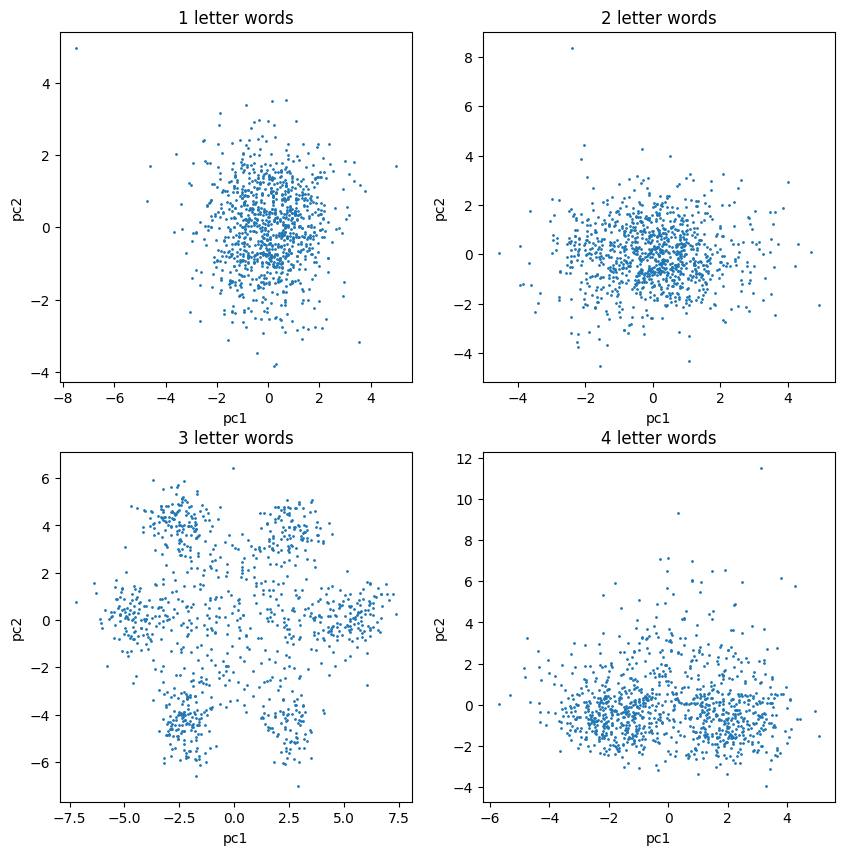

In [8]:
# Now, we finally need to plot these tables to try to find correlations visually
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(1, 5):
    plt.subplot(2, 2, i)
    
    x = pCompTables[i].loc[:,'pc1']
    
    y = pCompTables[i].loc[:,'pc2']
    
    plt.scatter(x, y, s = 1)
    
    plt.xlabel('pc1')
    
    plt.ylabel('pc2')
    
    plt.title(str(i) + ' letter words')

plt.show()

From the plots, we can clearly see that **3 letters** generates identifiable visual relations between data points in the first **two principal components**. **These 3 letter words are called codons in biology.**

**What do these point clouds (clusters) mean for the 3-letter words?** 

- We can identify 6 distinct poles, or centroids in the graph. If the genetic information is coded in 3-letter words, each of these clusters has similar distributions of frequencies of these words.

**Why 6 poles then?** 

- Well, since we don't know when a word starts, we can think that if we read the data point with the shift of 1 letter (i.e. not considering the first letter), it would still contain basically the same information. Therefore, in the 3 letter words hypothesis, we can find 3 distinct poles, each representing a shift in reading. The remaining 3 poles are explained since, we don't really know that all the genes read forward for the direction we chose for our strings, some might read backward, too. Hence, there are 6 poles for 3-letter words. 

- There are, however, 7 clusters, the last one being the points in the center of the figure, representing the bits of the code that do not carry information.

## **Clustering**
We will now cluster the 3 letter word gene breakdown using the K-means Clustering unsupervised algorithm. From the previous section, we can detect 6 or 7 clusters. Knowing that some genes do not carry information, we are led to think that the center points, far from the 6 distinct centroids, could be a candidate for those. We, therefore, assume that there are 7 clusters (this could be checked by comparing the performance with 6 or 7 clusters).

In [9]:
kmeans = KMeans(n_clusters = 7)

kmeans.fit(normFreqTables[3])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",7
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### **Results in a Graph**
Using our clustering results, we can visualize the different colors!

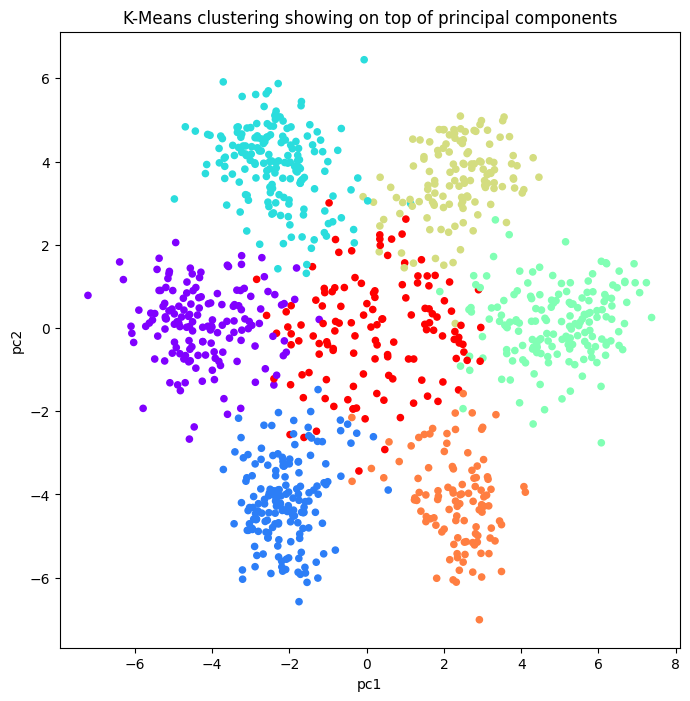

In [10]:
plt.figure(figsize = (8, 8))

x = pCompTables[3].loc[:,'pc1']

y = pCompTables[3].loc[:,'pc2']

plt.scatter(x, y, s = 20, c = kmeans.labels_, cmap = 'rainbow')

plt.xlabel('pc1')

plt.ylabel('pc2')

plt.title('K-Means clustering showing on top of principal components')

plt.show()

## **Conclusion**

Hence, Unsupervised Learning through Clustering (K-means Clustering) and Dimensionality Reduction (PCA) has allowed us to **visualize, validate, and provide supporting evidence for the biological discovery** that the DNA genetic sequence is organized into three-letter words called **codons**, which are responsible for the amino acids and proteins that are produced by living cells.